# Experiment 4: EfficientNetV2S (Frozen Base)

## Hypothesis

EfficientNetV2S is a more recent and more efficient architecture than
ResNet50. On ImageNet, EfficientNetV2S reaches 83.9% top-1 accuracy
versus 76.0% for ResNet50 — better base features should translate to
better waste classification.

The dataset paper (Kunwar, 2026) reports 95.13% accuracy on this exact
dataset using EfficientNetV2S. Our target: match or approach that result.

Expected gain over ResNet50 fine-tuned (93.29%): +1-2 pp.

## Configuration

For fair comparison with ResNet50 experiments:
- Same input size: 224x224 (despite EfficientNetV2S preferring 384)
- Same training pipeline, augmentations, optimizer
- Frozen base, classifier head only
- Adam, lr=1e-3, batch_size=32, max 30 epochs

This isolates the architecture's effect from input resolution.

In [8]:
import os
import shutil

if os.path.exists('trash-classification'):
    shutil.rmtree('trash-classification')

!git clone https://github.com/wayofell/trash-classification.git
%cd trash-classification

import sys
sys.path.insert(0, '.')

import tensorflow as tf
print(f"TF version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

Cloning into 'trash-classification'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 82 (delta 33), reused 68 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 5.23 MiB | 30.60 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/kaggle/working/trash-classification
TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
from src.data import load_dataset, CLASS_NAMES, NUM_CLASSES
from src.model import build_efficientnetv2s_transfer
from src.train import compile_and_train, evaluate_on_test
from src.utils import (
    log_experiment, plot_training_curves,
    collect_predictions, plot_confusion_matrix, print_classification_report,
    get_experiments_dir
)

print("All imports OK")

All imports OK


In [11]:
BATCH_SIZE = 32

train_ds, val_ds, test_ds, sizes = load_dataset(batch_size=BATCH_SIZE)

print("Dataset sizes:")
for split, n in sizes.items():
    print(f"  {split:5s}: {n:>5d} samples ({n // BATCH_SIZE} batches)")

Dataset sizes:
  train:  8593 samples (268 batches)
  val  :  1833 samples (57 batches)
  test :  1833 samples (57 batches)


In [12]:
model = build_efficientnetv2s_transfer(trainable_base=False)

trainable_params = sum(
    tf.keras.backend.count_params(w) for w in model.trainable_weights
)
non_trainable_params = model.count_params() - trainable_params

print(f"Total parameters:         {model.count_params():>12,}")
print(f"Trainable parameters:     {trainable_params:>12,}")
print(f"Non-trainable parameters: {non_trainable_params:>12,}")
print(f"\nComparison with ResNet50:")
print(f"  Total params:     EffNetV2S has {(20341538 - 23608202)/23608202*100:.1f}% vs ResNet50")
print(f"  Trainable params: EffNetV2S has {(12810 - 20490)/20490*100:.1f}% vs ResNet50")

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters:           20,344,170
Trainable parameters:           12,810
Non-trainable parameters:   20,331,360

Comparison with ResNet50:
  Total params:     EffNetV2S has -13.8% vs ResNet50
  Trainable params: EffNetV2S has -37.5% vs ResNet50


In [14]:
EPOCHS = 30
LEARNING_RATE = 1e-3

history, training_time = compile_and_train(
    model=model,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    optimizer_name="adam",
    class_weight=None,
    verbose=2,
)

print(f"\nTraining finished in {training_time:.1f} seconds "
      f"({training_time/60:.1f} minutes)")
print(f"Total epochs run: {len(history.history['loss'])}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/30
269/269 - 132s - 490ms/step - accuracy: 0.8243 - loss: 0.6451 - val_accuracy: 0.8996 - val_loss: 0.3429 - learning_rate: 1.0000e-03
Epoch 2/30
269/269 - 19s - 72ms/step - accuracy: 0.9048 - loss: 0.3221 - val_accuracy: 0.9083 - val_loss: 0.2908 - learning_rate: 1.0000e-03
Epoch 3/30
269/269 - 19s - 71ms/step - accuracy: 0.9148 - loss: 0.2783 - val_accuracy: 0.9149 - val_loss: 0.2682 - learning_rate: 1.0000e-03
Epoch 4/30
269/269 - 19s - 72ms/step - accuracy: 0.9223 - loss: 0.2507 - val_accuracy: 0.9171 - val_loss: 0.2542 - learning_rate: 1.0000e-03
Epoch 5/30
269/269 - 19s - 71ms/step - accuracy: 0.9245 - loss: 0.2391 - val_accuracy: 0.9187 - val_loss: 0.2434 - learning_rate: 1.0000e-03
Epoch 6/30
269/269 - 19s - 72ms/step - accuracy: 0.9238 - loss: 0.2266 - val_accuracy: 0.9203 - val_loss: 0.2407 - learning_rate: 1.0000e-03
Epoch 7/30
269/269 - 19s - 70ms/step - accuracy: 0.9277 - loss: 0.2157 - val_accuracy: 0.9203 - val_loss: 0.2357 - learning_rate: 1.0000e-03
Epoch 8/30


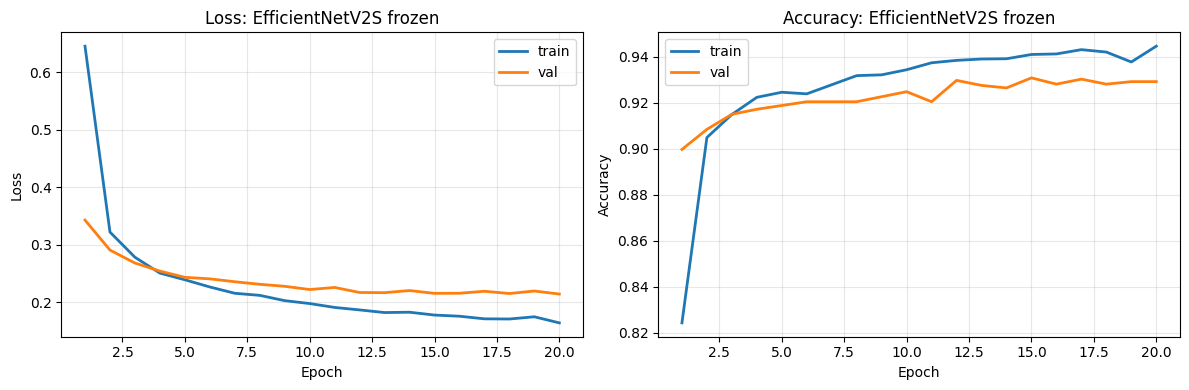

In [15]:
plots_dir = get_experiments_dir() / "plots"
plot_training_curves(
    history,
    title="EfficientNetV2S frozen",
    save_path=plots_dir / "04_efficientnetv2s_frozen_curves.png"
)

In [16]:
test_loss, test_acc = evaluate_on_test(model, test_ds)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")

# Comparison
print(f"\n--- Comparison ---")
print(f"Baseline CNN:           78.61%")
print(f"ResNet50 frozen:        92.69%")
print(f"ResNet50 fine-tuned:    93.29%")
print(f"EfficientNetV2S frozen: {test_acc * 100:.2f}%")
print(f"Paper benchmark:        95.13%  (target)")
print(f"\nGap to paper: {(0.9513 - test_acc) * 100:+.2f} pp")

Test loss:     0.2251
Test accuracy: 0.9253 (92.53%)

--- Comparison ---
Baseline CNN:           78.61%
ResNet50 frozen:        92.69%
ResNet50 fine-tuned:    93.29%
EfficientNetV2S frozen: 92.53%
Paper benchmark:        95.13%  (target)

Gap to paper: +2.60 pp


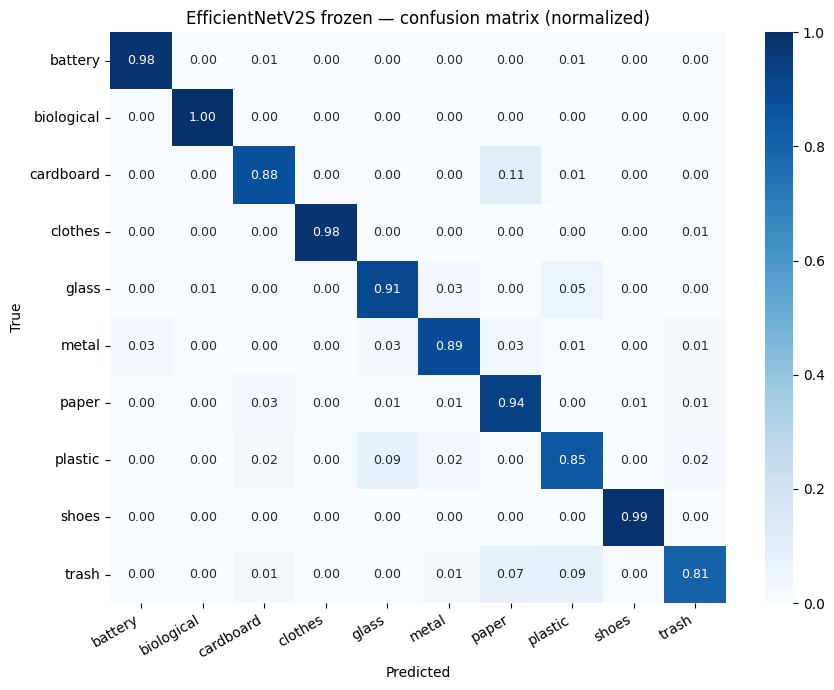

In [17]:
y_true, y_pred = collect_predictions(model, test_ds)

cm = plot_confusion_matrix(
    y_true, y_pred,
    class_names=CLASS_NAMES,
    title="EfficientNetV2S frozen — confusion matrix (normalized)",
    normalize=True,
    save_path=plots_dir / "04_efficientnetv2s_frozen_confusion.png"
)

In [18]:
from sklearn.metrics import f1_score

report = print_classification_report(y_true, y_pred, CLASS_NAMES)
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"\nMacro F1: {macro_f1:.4f}")
print(f"vs ResNet50 fine-tuned (0.9248): {(macro_f1 - 0.9248):+.4f}")

              precision    recall  f1-score   support

     battery      0.949     0.982     0.965       113
  biological      0.972     1.000     0.986       104
   cardboard      0.939     0.877     0.907       211
     clothes      1.000     0.982     0.991       283
       glass      0.897     0.908     0.902       260
       metal      0.892     0.892     0.892       139
       paper      0.846     0.935     0.888       200
     plastic      0.894     0.845     0.869       239
       shoes      0.991     0.991     0.991       217
       trash      0.794     0.806     0.800        67

    accuracy                          0.925      1833
   macro avg      0.917     0.922     0.919      1833
weighted avg      0.926     0.925     0.925      1833


Macro F1: 0.9191
vs ResNet50 fine-tuned (0.9248): -0.0057


In [19]:
log_experiment({
    "experiment_name": "04_efficientnetv2s_frozen",
    "model": "efficientnetv2s_imagenet_frozen",
    "epochs": len(history.history['loss']),
    "batch_size": BATCH_SIZE,
    "optimizer": "adam",
    "learning_rate": LEARNING_RATE,
    "augmentation": "flip+brightness+contrast",
    "class_weights": "none",
    "train_acc": round(history.history['accuracy'][-1], 4),
    "val_acc": round(max(history.history['val_accuracy']), 4),
    "test_acc": round(test_acc, 4),
    "test_macro_f1": round(macro_f1, 4),
    "train_loss": round(history.history['loss'][-1], 4),
    "val_loss": round(min(history.history['val_loss']), 4),
    "test_loss": round(test_loss, 4),
    "training_time_sec": round(training_time, 1),
    "notes": "alternative architecture (paper baseline backbone), frozen ImageNet",
})

import pandas as pd
df = pd.read_csv(get_experiments_dir() / "results.csv")
print(df.to_string(index=False))

          timestamp           experiment_name                                model  epochs  batch_size optimizer learning_rate             augmentation class_weights  train_acc  val_acc  test_acc  test_macro_f1  train_loss  val_loss  test_loss  training_time_sec                                                               notes
2026-05-16T17:27:12           01_baseline_cnn                  baseline_cnn_4block      30          32      adam         0.001 flip+brightness+contrast          none     0.7767   0.7889    0.7861         0.7797      0.6716    0.6895     0.6694              322.5                                baseline reference, no class weights
2026-05-18T15:20:53        02_resnet50_frozen             resnet50_imagenet_frozen      17          32      adam         0.001 flip+brightness+contrast          none     0.9604   0.9296    0.9269         0.9196      0.1111    0.2523     0.2182              269.9                         transfer learning with frozen ImageNet base
2026-05

## Findings

### Overall performance
- EfficientNetV2S frozen reached **92.53%** test accuracy, macro F1 **0.919**
- Slightly below ResNet50 frozen (92.69%) and ResNet50 fine-tuned (93.29%)
- Gap to paper benchmark (95.13%): **2.60 pp**

### Why EfficientNetV2S did not outperform ResNet50 here
EfficientNetV2S is designed for 384x384 input via compound scaling
(resolution, depth, and width are jointly optimized). We used 224x224 for
a fair comparison with ResNet50, which operates at its native resolution.
This explains:
- Why EffNetV2S matched rather than beat ResNet50 (it was off its design point)
- The 2.6pp gap to the paper, which used 384x384 (EffNet's native resolution)

This is a methodologically important finding: architecture choice cannot be
separated from input resolution for EfficientNet-family models.

### Generalization quality
Despite slightly lower accuracy, EfficientNetV2S showed the cleanest training:
- Train-val gap ~1.5% (vs ~6% for ResNet50 fine-tuned)
- Minimal overfitting — train 94.5%, val 93.0%
This suggests EfficientNetV2S is the more robust architecture even at 224x224.

### Per-class differences vs ResNet50 fine-tuned
- biological: reached 1.00 recall (perfect)
- paper: 0.94 — best paper result across all models
- plastic: dropped to 0.85 (EffNet weaker on plastic)
- cardboard: dropped to 0.88 (notable cardboard->paper confusion at 11%)

### Trash class: definitive bottleneck confirmation
trash recall = 0.81 in all three transfer experiments (ResNet50 frozen,
ResNet50 fine-tuned, EfficientNetV2S). Three different configurations,
identical ceiling. This confirms the limiting factor for trash is data
(few samples, high variance), not architecture or feature quality.
Class weighting is the remaining lever — addressed in the next experiment.

## Discussion

ResNet50 fine-tuned remains the best model so far (93.29%). EfficientNetV2S
is competitive and generalizes better, but to exploit its full potential
would require 384x384 input — a possible future experiment (the dataset
provides a standardized_384 version).